In [1]:
############################################################
# Headers

import os
import re
import sys
import cProfile
import configparser
import copy
from background import *

from FDM import *
from base import *
from init import *
from base.data_field import *
from base.grid import *
from base.profile_base import *
from base.source import *
from base.unit import *
from main import config_setup
import numpy      as  np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
plt.rcParams[ 'image.cmap' ] = 'turbo'
import numpy as np
np.set_printoptions(edgeitems=3)
np.core.arrayprint._line_width = 30
from binary_io  import binary_io



In [2]:
config_setup( "setup.par" )

In [3]:
# Background components can be adjusted
all_comp = { "bar_portail" : 1, "disc_s22" : 1, "nsc_s20" : 1, "nsd_s20" : 1 }
bg = background( all_components={} )

In [4]:

# Profile_flags can be adjusted
# Examples: disc, sech2, gauss, exp. zsolve is only applicable vertically
prof = profile( profile_flags=[ "disc", "sech2" ], 
                scale_lengths=[ [ 1500, 7000 ], [ 250 ] ],
                background=bg,
                config_flag='output_grid' )

Coords/mesh already in target coordinates


/mnt/scratch/cmz/setup/base/data_field.py:296: RuntimeWarning: divide by zero encountered in divide
  def __truediv__( self, obj )  : return self._binary_op( obj, lambda a, b : a / b , False )
/mnt/scratch/cmz/setup/base/data_field.py:296: RuntimeWarning: overflow encountered in divide
  def __truediv__( self, obj )  : return self._binary_op( obj, lambda a, b : a / b , False )
/mnt/scratch/cmz/setup/base/data_field.py:295: RuntimeWarning: invalid value encountered in multiply
  def __mul__( self, obj )      : return self._binary_op( obj, lambda a, b : a * b , False )


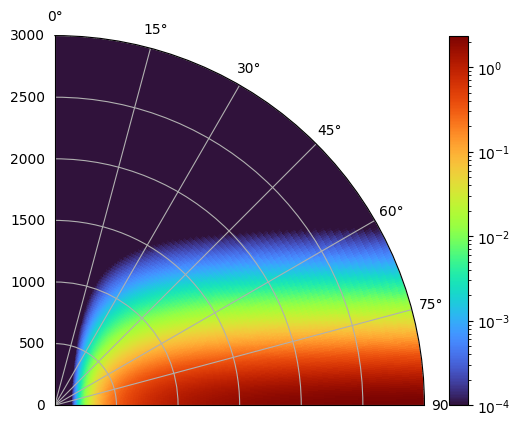

In [5]:
import matplotlib as mpl
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
s = ax.pcolormesh(prof.grid[ 1 ], prof.grid[ 0 ], prof.densprof, norm=mpl.colors.LogNorm(vmin=1e-4))
#s = ax.pcolormesh(prof.grid[ 1 ], prof.grid[ 0 ], prof.velprof )#, norm=mpl.colors.LogNorm(vmin=1e-4))
plt.ylim([0,3000])
plt.xlim([0,np.pi/2])
plt.colorbar(s)


In [6]:
fname = "../init/galaxy_init.bin"
IC( prof, fname, use_background=False )

[512 256]


[]


KeyError: 'bar_data'

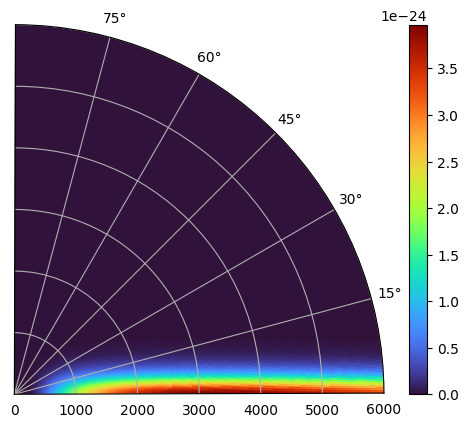

In [7]:
############################################################
# Check the data generating results
##############################
from matplotlib.pyplot import figure, pcolormesh
from numpy import pi

pc = units.pc

tst = binary_io( fname );
tst.open(  );
tst.read(  );

########################################
# Hydro init cond

fig = figure( 0 )
ax  = fig.add_subplot( 111, projection = 'polar' );

aa = tst.as_array( 'hydro_rho' );
rr = tst.as_array( 'hydro_x_0'  );
tt = pi / 2 - tst.as_array( 'hydro_x_1'  );
# pi / 2 - theta for plots only! In Python's polar grid
# the polar angule is actually the latitutde

dd = aa.reshape( len( rr ), len( tt ) );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd )#, norm =
                     #LogNorm( vmin = 1e-26, vmax= 1e-21 ) )
cbar = fig.colorbar( pcm )
ax.set_ylim( 0, 6000 )
print(dd[np.isnan(dd)])
########################################
# Bar field

aa = tst.as_array( 'bar_data' );
rr = tst.as_array( 'bar_x_0'  );
tt = pi / 2 - tst.as_array( 'bar_x_1'  );
pp = tst.as_array( 'bar_x_2'  );
dd = aa.reshape( len( rr ), len( tt ), len( pp ) );

# Plot the r--theta slices
fig = figure( 1 )
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd[ :, :, 0 ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

fig = figure( 2 )
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd[ :, :, -1 ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

# Plot the equatorial plance profile
fig = figure( 3 )
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( pp.min(  ), pp.max(  ) )
pcm = ax.pcolormesh( pp, rr / pc, dd[ :, -1, : ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

print(dd[np.isnan(dd)])
########################################
# BG DM field

aa = tst.as_array( 'bg_data' );
rr = tst.as_array( 'bg_x_0'  );
tt = pi / 2 - tst.as_array( 'bg_x_1'  );
dd = aa.reshape( len( rr ), len( tt ) );

fig = figure( 4 )
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd, norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )

cbar = fig.colorbar( pcm )
##############################
# Close the binary_io object
print(dd[np.isnan(dd)])
tst.close(  );
#plt.savefig("test.png",dpi=300)
############################################################